## Importation des packages

In [6]:

# Importer les modules nécessaires
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Chargement des données

Les données concernent  des informations sur les paiements en défaut, les facteurs démographiques, les données de crédit, l'historique des paiements et les relevés de compte des clients de cartes de crédit à Taïwan d'avril 2005 à septembre 2005.

In [7]:
credit_data = pd.read_csv('UCI_Credit_Card.csv', sep=",", index_col=0)

In [9]:

credit_data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Informations sur l'ensemble de données

Cet ensemble de données contient des informations sur les paiements en défaut, les facteurs démographiques, les données de crédit, l'historique des paiements et les relevés de compte des clients de cartes de crédit à Taïwan d'avril 2005 à septembre 2005.

- ID : Identifiant de chaque client

- LIMIT_BAL : Montant du crédit accordé en dollars NT (incluant les crédits individuels et familiaux/supplémentaires)

- SEXE : Genre (1=homme, 2=femme)

- ÉDUCATION : (1=études supérieures, 2=université, 3=lycée, 4=autres, 5=inconnu, 6=inconnu)

- MARRIAGE : État civil (1=marié, 2=célibataire, 3=autre)

- ÂGE : Âge en années

- PAY_0 : État du remboursement en septembre 2005 (-1=paiement à l'échéance, 1=retard de paiement d'un mois, 2=retard de paiement de deux mois, … 8=retard de paiement de huit mois, 9=retard de paiement de neuf mois et plus)

- PAY_2 : État des remboursements en août 2005 (échelle identique à celle ci-dessus)

- PAY_3 : État du remboursement en juillet 2005 (échelle identique à celle ci-dessus)

- PAY_4 : État des remboursements en juin 2005 (échelle identique à celle ci-dessus)

- PAY_5 : État du remboursement en mai 2005 (échelle identique à celle ci-dessus)

- PAY_6 : État des remboursements en avril 2005 (échelle identique à celle ci-dessus)

- BILL_AMT1 : Montant de la facture de septembre 2005 (dollar NT)

- BILL_AMT2 : Montant de la facture en août 2005 (dollar NT)

- BILL_AMT3 : Montant de la facture de juillet 2005 (dollar NT)

- BILL_AMT4 : Montant de la facture de juin 2005 (dollar NT)

- BILL_AMT5 : Montant de la facture de mai 2005 (dollar NT)

- BILL_AMT6 : Montant de la facture d'avril 2005 (dollar NT)

- PAY_AMT1 : Montant du paiement précédent en septembre 2005 (dollar NT)

- PAY_AMT2 : Montant du paiement précédent en août 2005 (dollar NT)

- PAY_AMT3 : Montant du paiement précédent en juillet 2005 (dollar NT)

- PAY_AMT4 : Montant du paiement précédent en juin 2005 (dollar NT)

- PAY_AMT5 : Montant du paiement précédent en mai 2005 (dollar NT)

- PAY_AMT6 : Montant du paiement précédent en avril 2005 (dollar NT)

- default.payment.next.month : Paiement par défaut (1=oui, 0=non)

## Exploration des données 

In [10]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   30000 no

In [11]:
credit_data.describe(include='all')


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [12]:
credit_data.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [14]:
# Créer une nouvelle version de la base de données sans la variable "default payment next month "
credit_data_new = credit_data.drop(columns=['default.payment.next.month'])
credit_data_new.head()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
2,120000.0,2,2,2,26,-1,2,0,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
3,90000.0,2,2,2,34,0,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
4,50000.0,2,2,1,37,0,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0


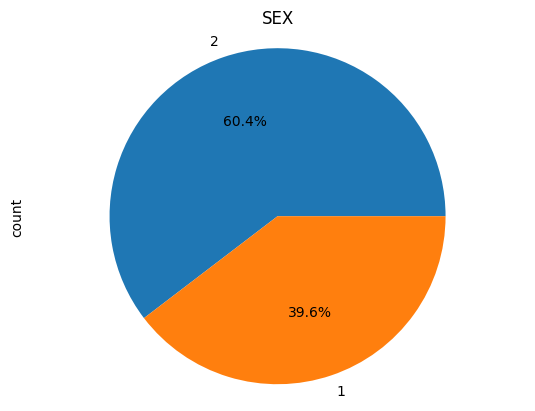

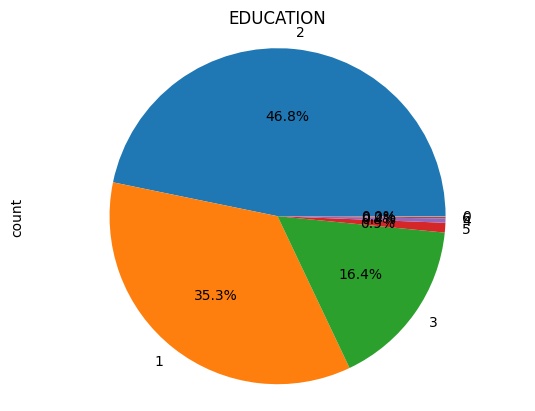

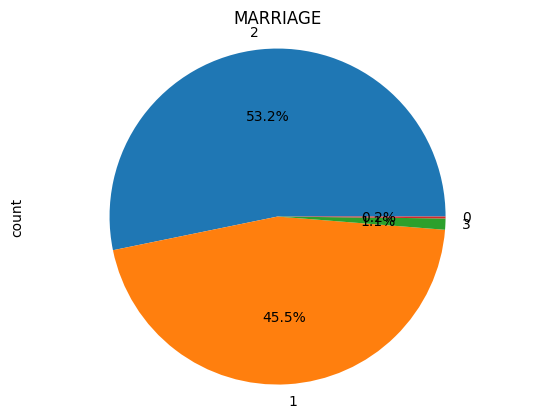

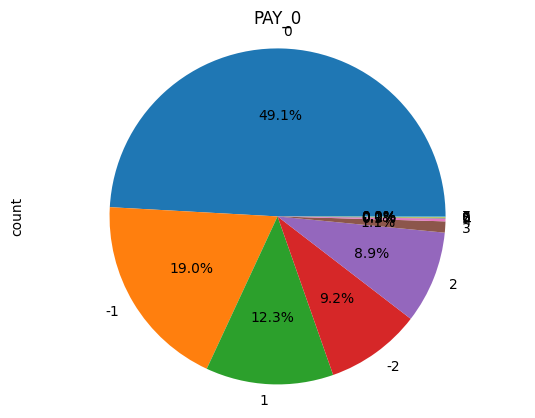

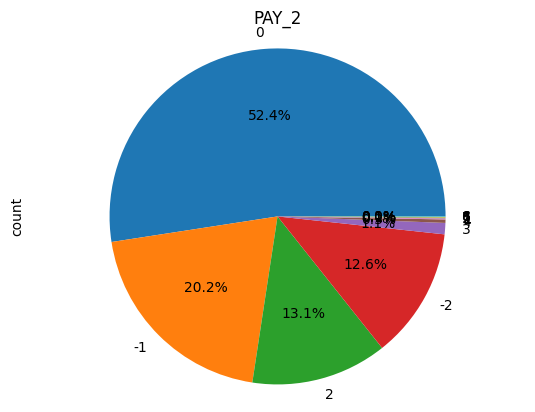

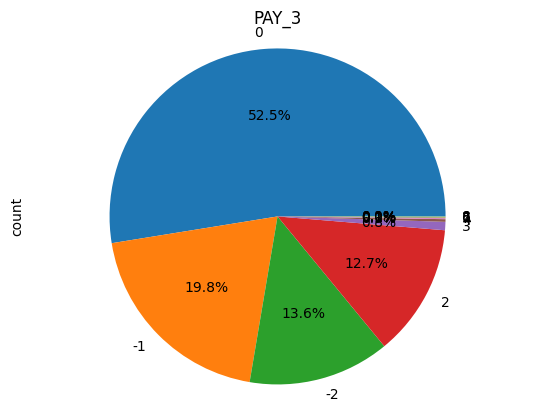

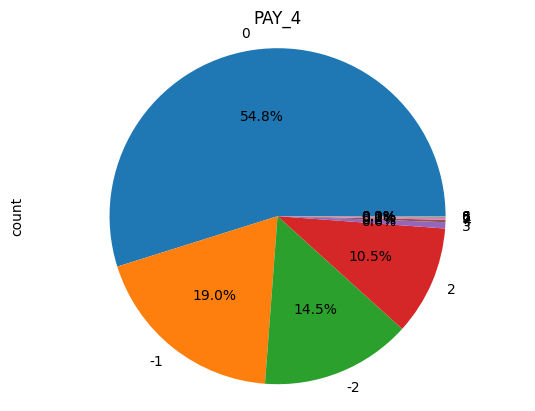

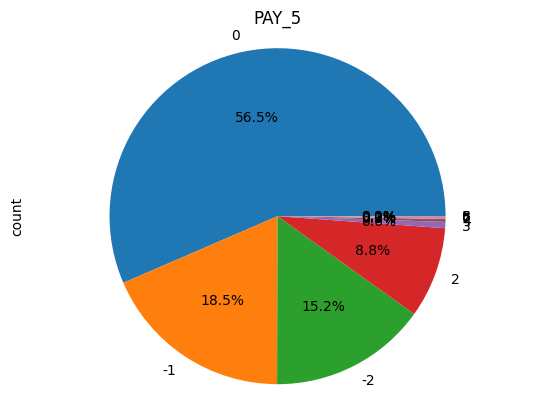

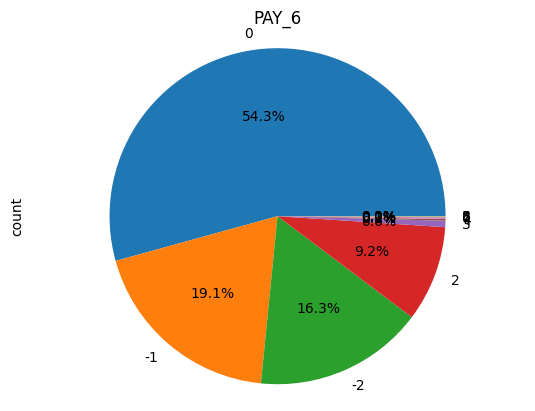

In [15]:
# Sélectionner les variables catégorielles
categorical_vars = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Générer un pie plot pour chaque variable catégorielle
for var in categorical_vars:
    credit_data[var].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(var)
    plt.axis('equal')
    plt.show()

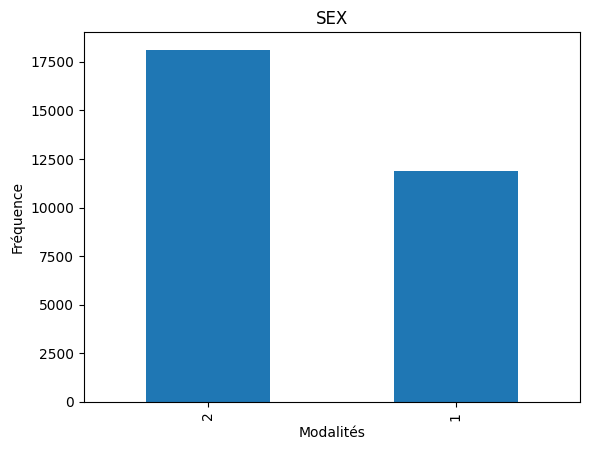

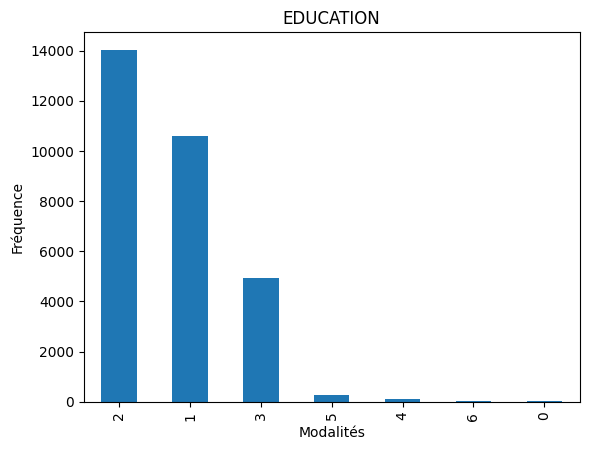

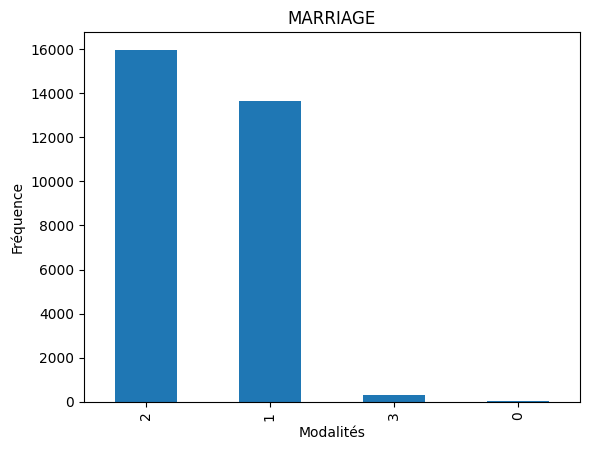

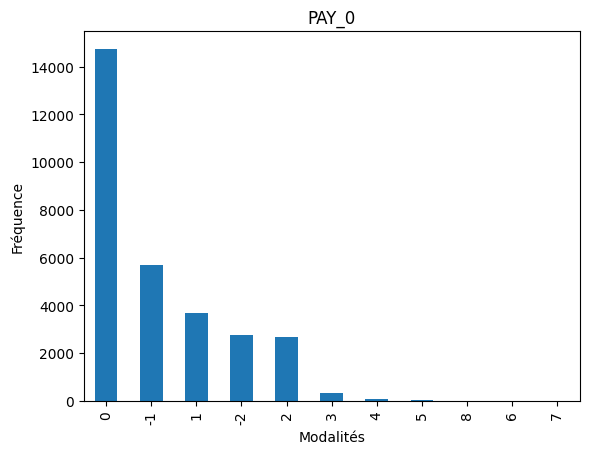

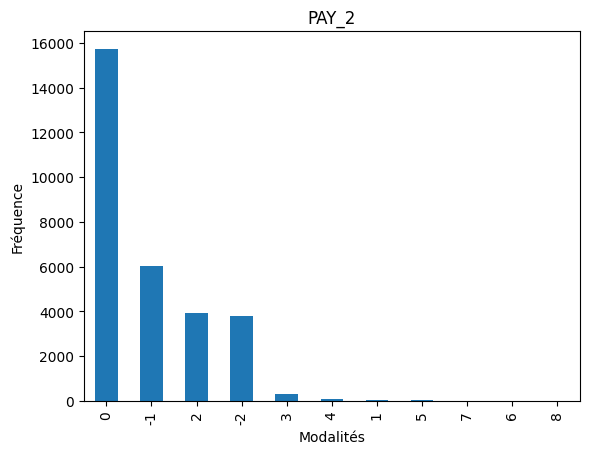

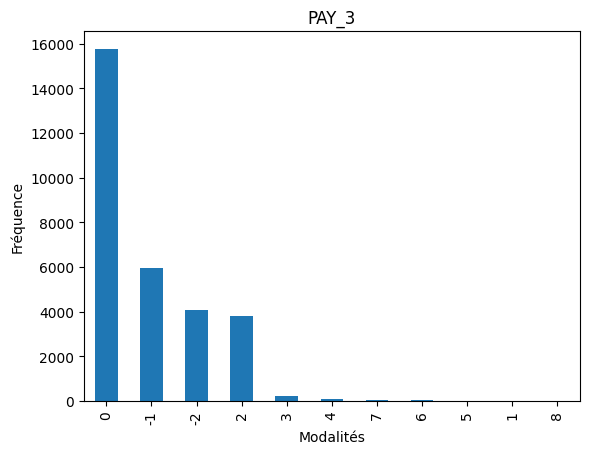

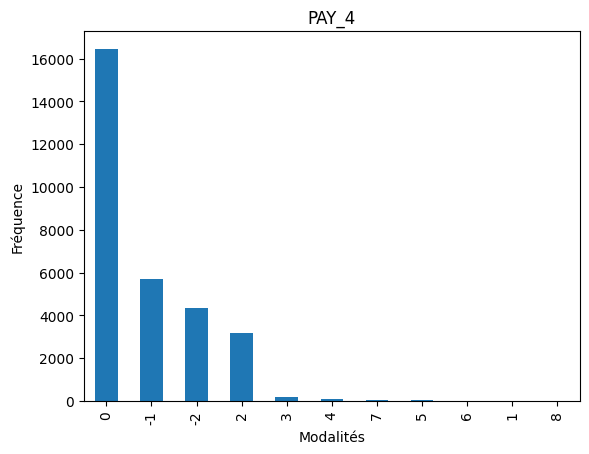

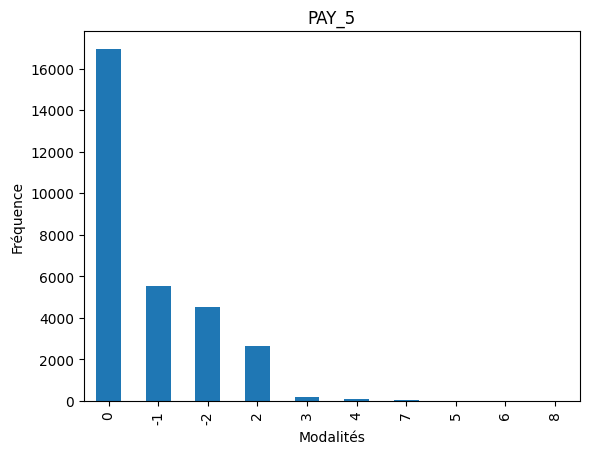

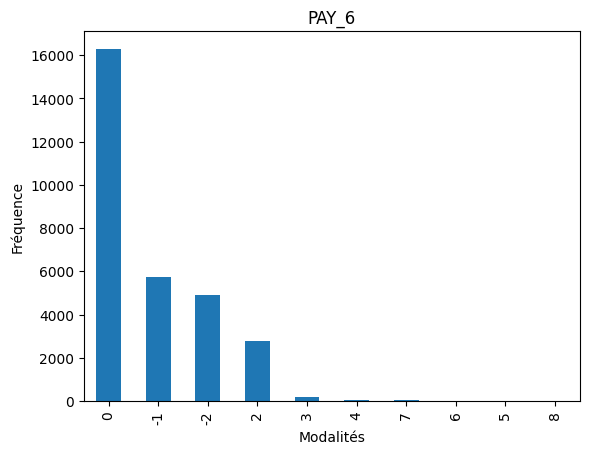

In [16]:
# Générer un bar plot pour chaque variable catégorielle
for var in categorical_vars:
    credit_data_new[var].value_counts().plot(kind='bar')
    plt.title(var)
    plt.xlabel('Modalités')
    plt.ylabel('Fréquence')
    plt.show()

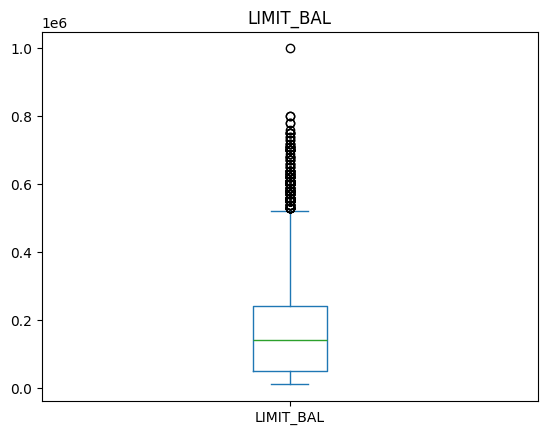

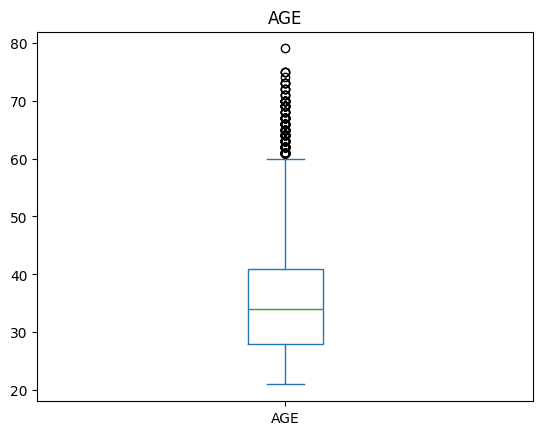

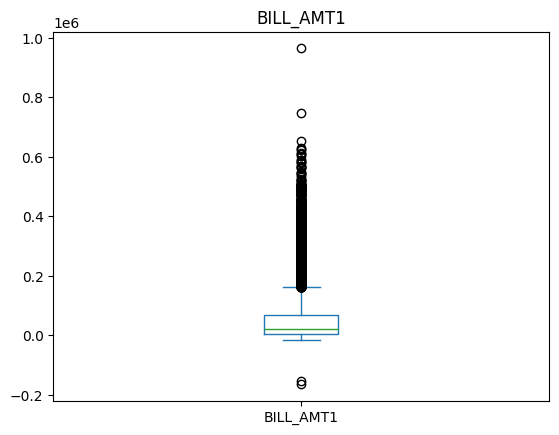

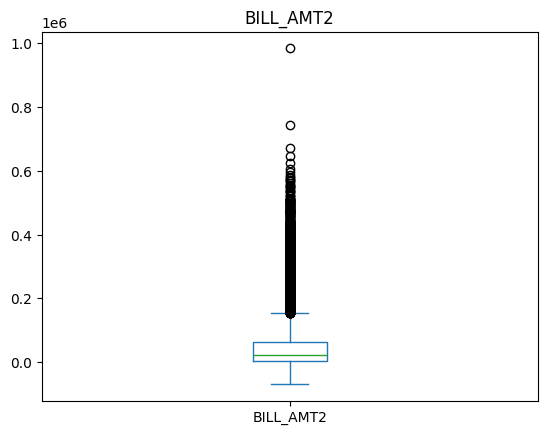

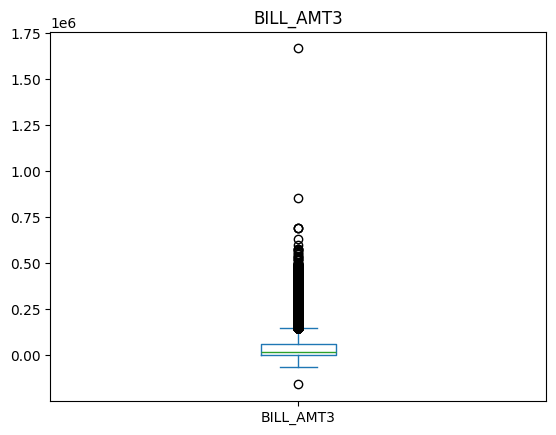

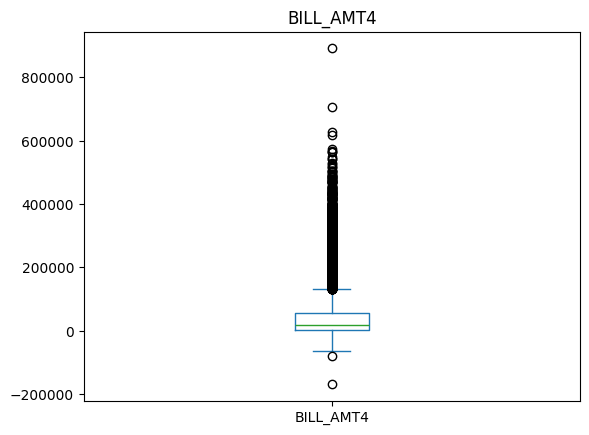

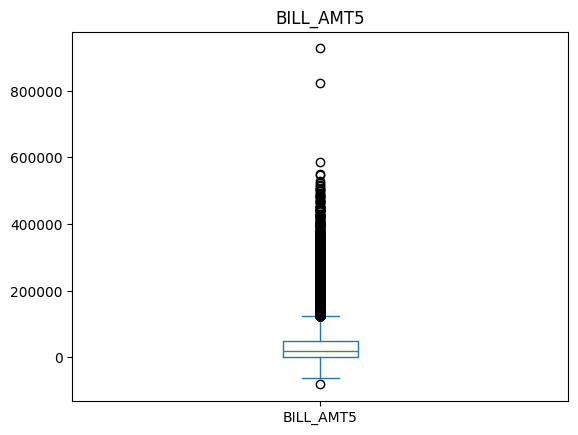

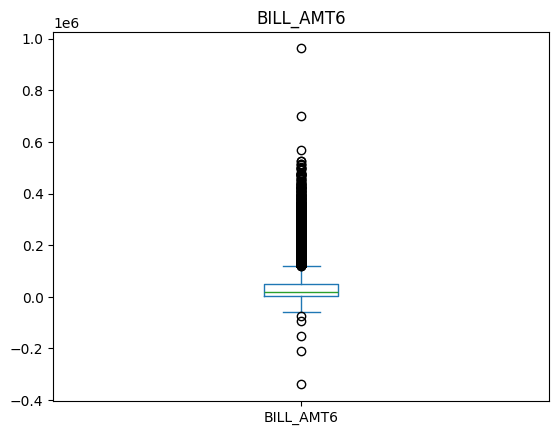

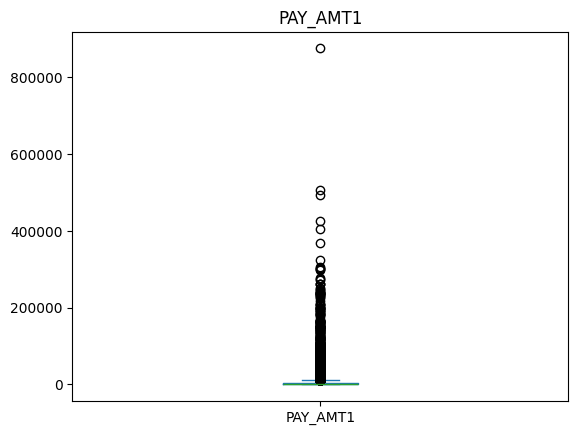

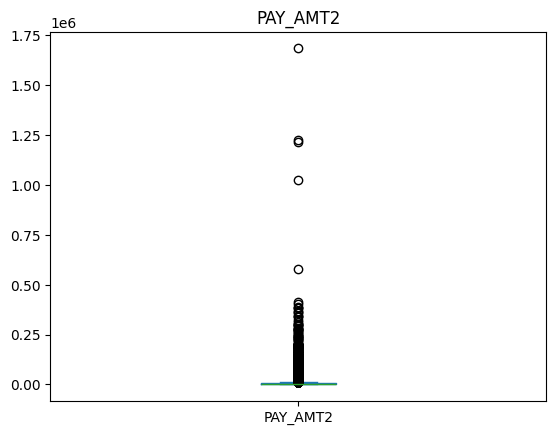

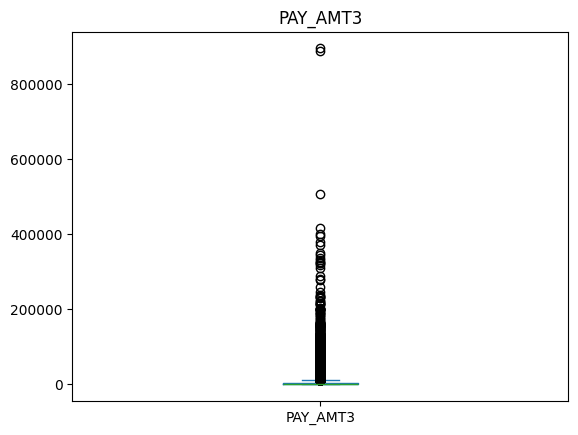

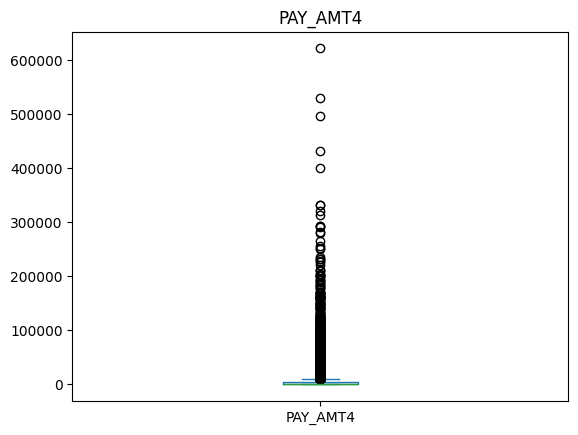

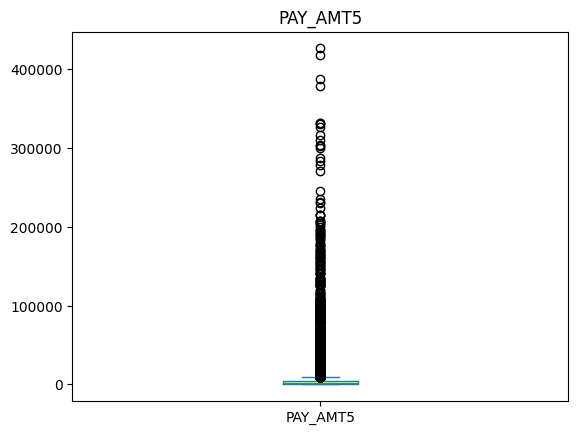

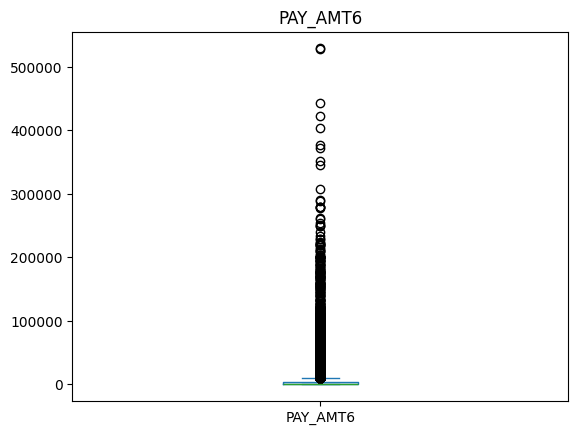

In [17]:

# Sélectionner les variables numériques
num_vars = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
            'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 
            'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Générer un box plot pour chaque variable numérique
for var in num_vars:
    credit_data_new[var].plot(kind='box')
    plt.title(var)
    plt.show()

## Analyse bivariée

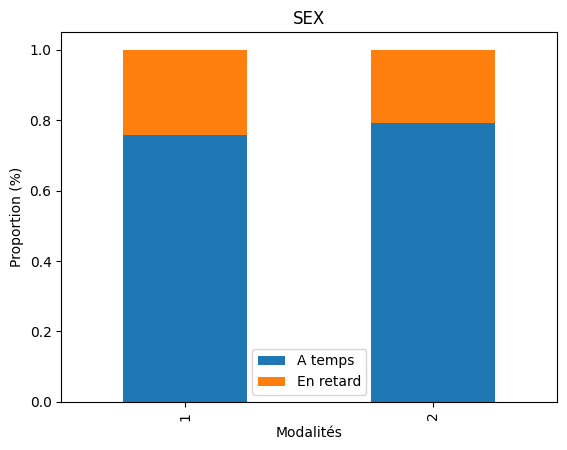

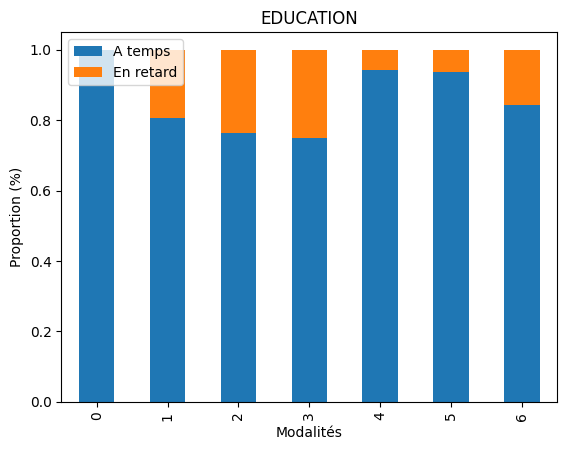

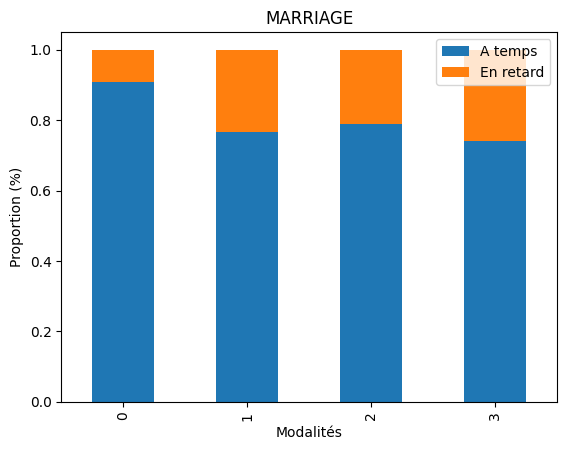

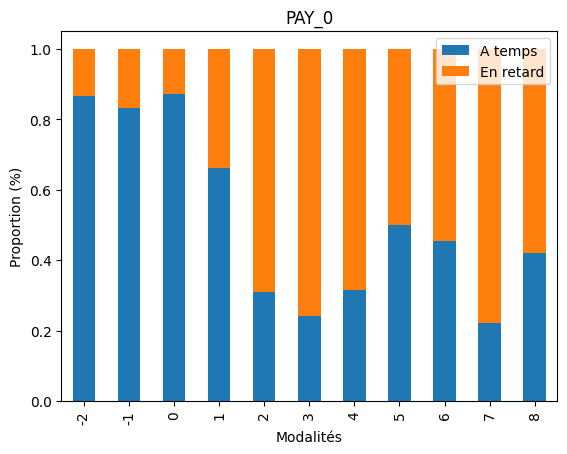

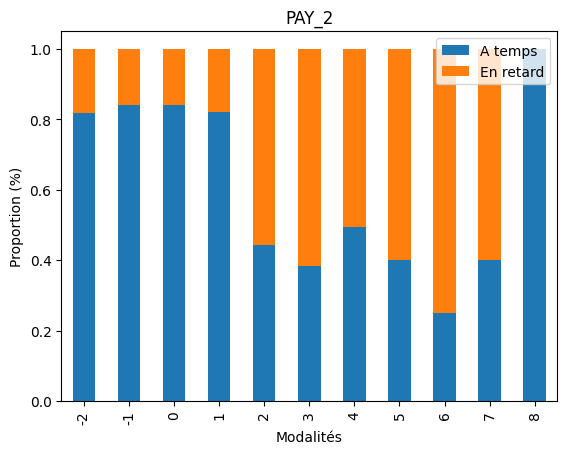

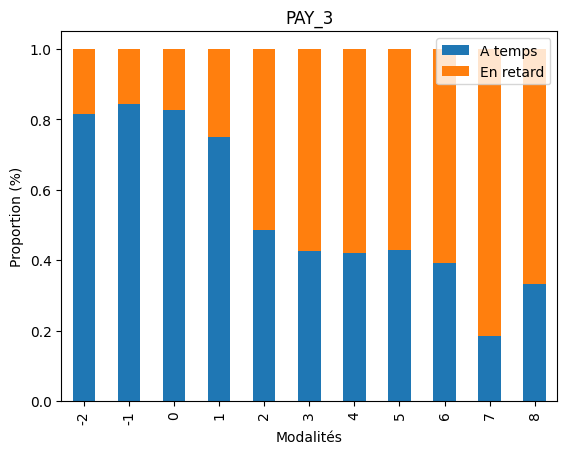

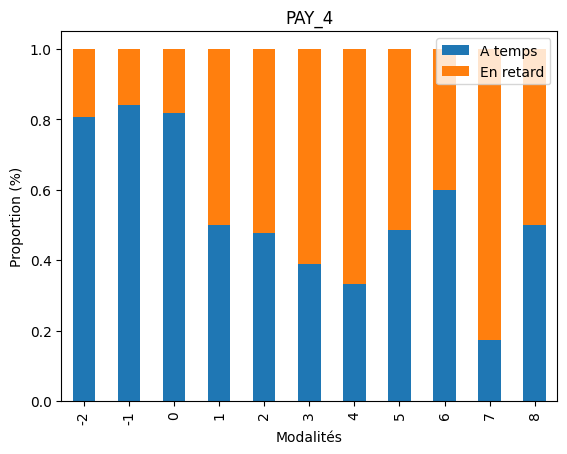

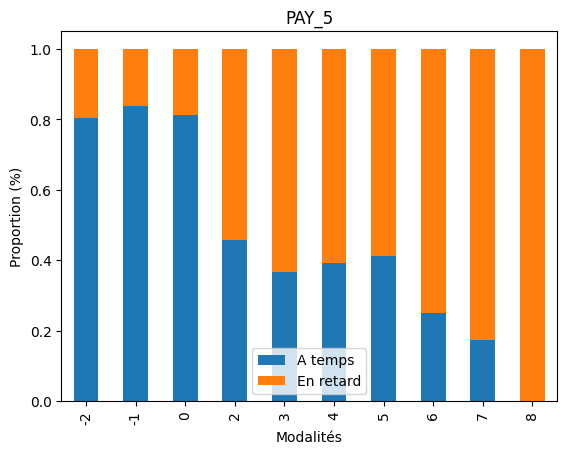

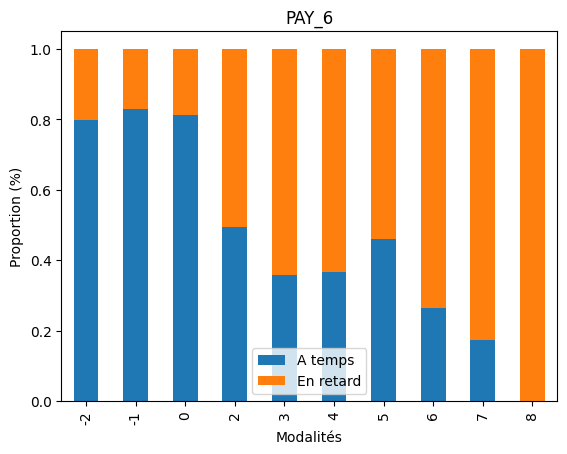

In [19]:

import seaborn as sns
# Sélectionner les variables catégorielles

# Générer un bar plot pour chaque variable catégorielle
for var in categorical_vars:
    figsize = (20, 20)
    (credit_data.groupby([var, 'default.payment.next.month'])['default.payment.next.month'].count()/credit_data_new.groupby([var])[var].count()).unstack(level=1).plot(kind='bar', stacked=True)
    plt.title(var)
    plt.xlabel('Modalités')
    plt.ylabel('Proportion (%)')
    plt.legend(['A temps', 'En retard'])
    plt.show()

In [22]:
from scipy.stats import chi2_contingency
# Initialiser les listes pour stocker les résultats
var_names = []
chi2_stats = []
p_values = []
cramer_vs = []

# Parcourir toutes les variables catégorielles
for var in categorical_vars:
    # Calculer le tableau de contingence
    contingency_table = pd.crosstab(credit_data['default.payment.next.month'], credit_data[var])
    # Calculer la statistique de test du Khi-deux et la p-valeur
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # Calculer le coefficient V de Cramer
    n = contingency_table.sum().sum()
    phi2 = chi2/n
    r,k = contingency_table.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rc = r-((r-1)**2)/(n-1)
    kc = k-((k-1)**2)/(n-1)
    cramer_v = np.sqrt(phi2corr/min(rc-1,kc-1))
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    chi2_stats.append(chi2)
    p_values.append(p)
    cramer_vs.append(cramer_v)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Khi2': chi2_stats,
    'P-valeur': p_values,
    'V de Cramer': cramer_vs
})

# Trier le DataFrame par ordre croissant de V de Cramer
results_df.sort_values(by='V de Cramer', inplace=True,ascending=False)

# Afficher le tableau des résultats
print(results_df)

    Variable         Khi2      P-valeur  V de Cramer
3      PAY_0  5365.964977  0.000000e+00     0.422538
4      PAY_2  3474.466790  0.000000e+00     0.339832
5      PAY_3  2622.462128  0.000000e+00     0.295102
6      PAY_4  2341.469945  0.000000e+00     0.278780
7      PAY_5  2197.694901  0.000000e+00     0.270109
8      PAY_6  1886.835309  0.000000e+00     0.250193
1  EDUCATION   163.216558  1.233263e-32     0.072393
0        SEX    47.708797  4.944679e-12     0.039459
2   MARRIAGE    35.662396  8.825862e-08     0.032997


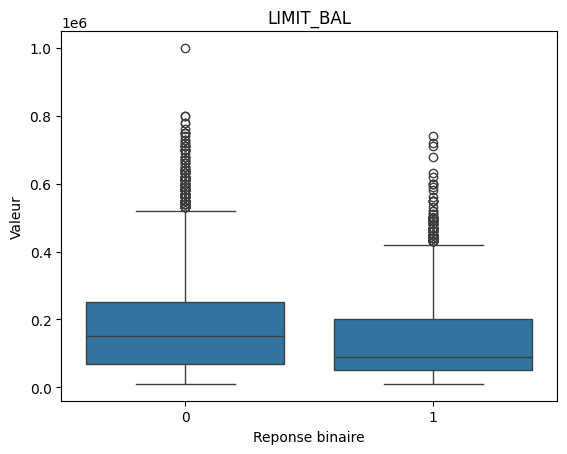

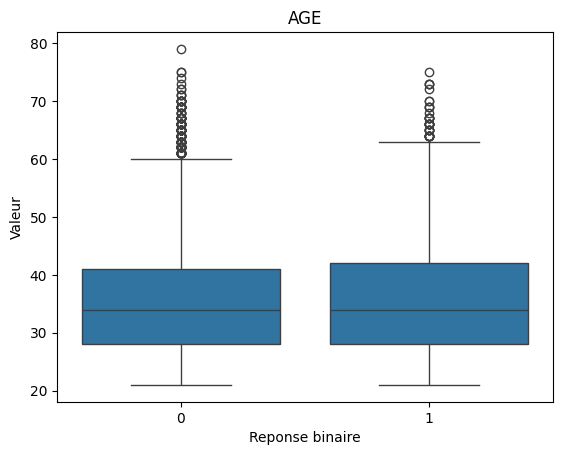

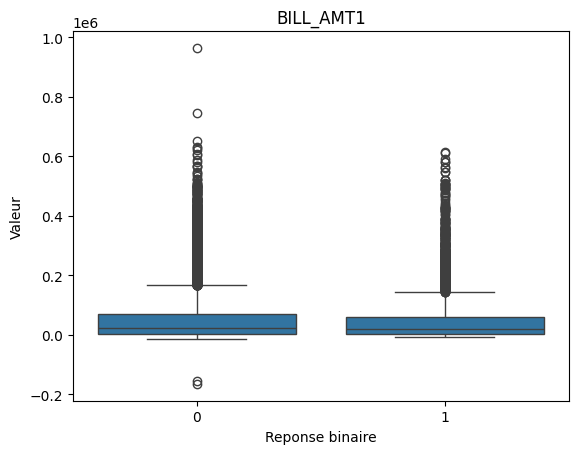

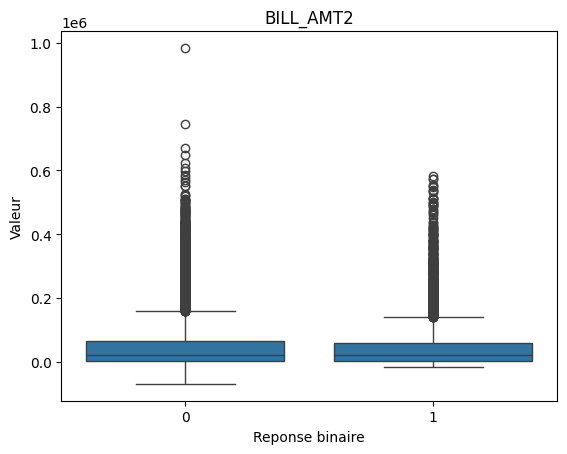

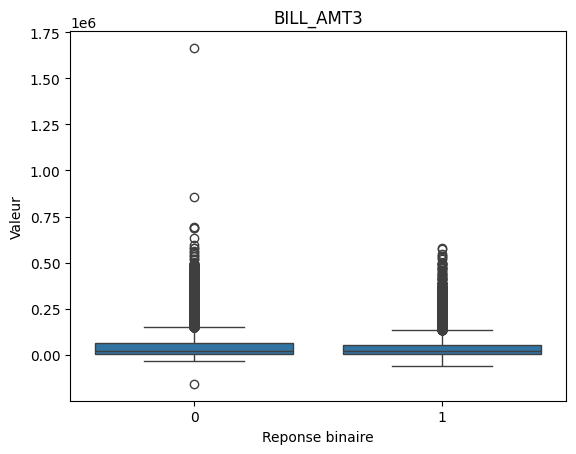

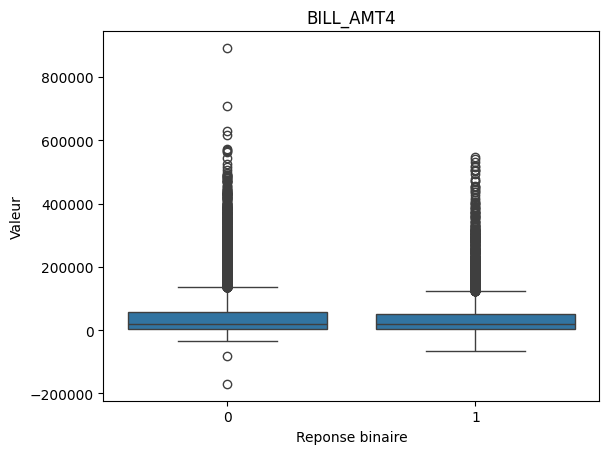

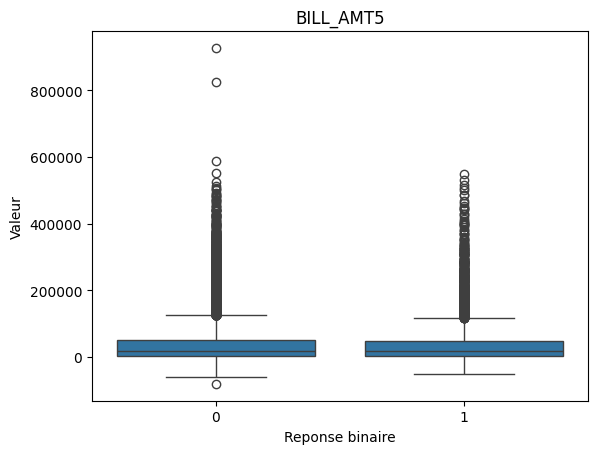

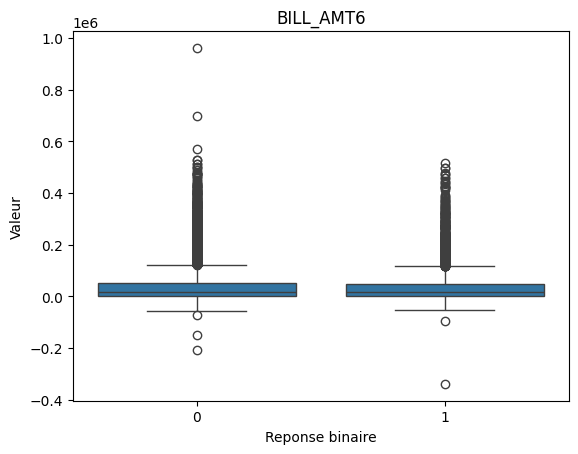

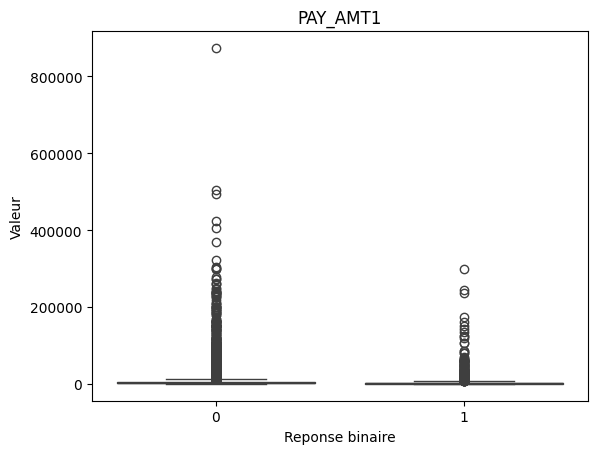

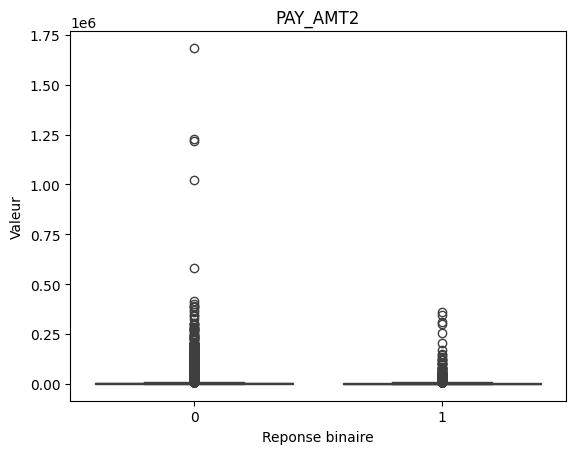

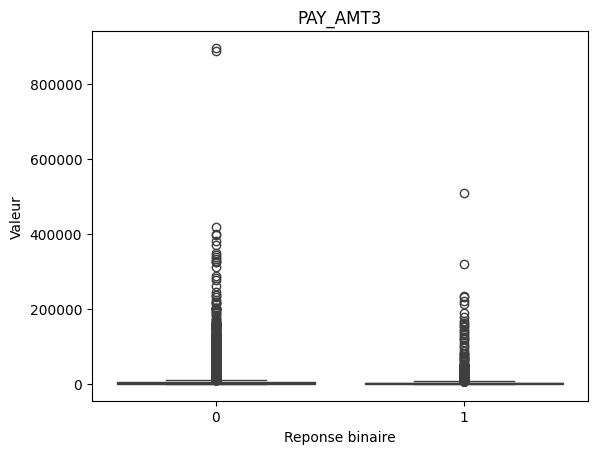

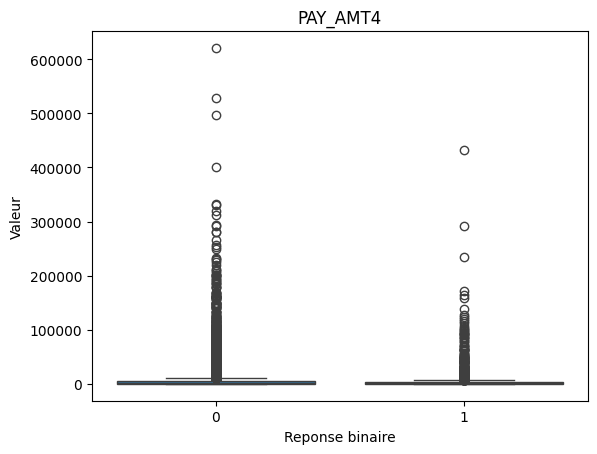

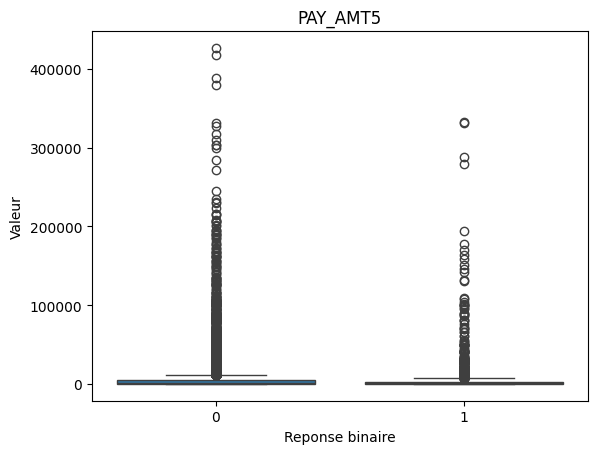

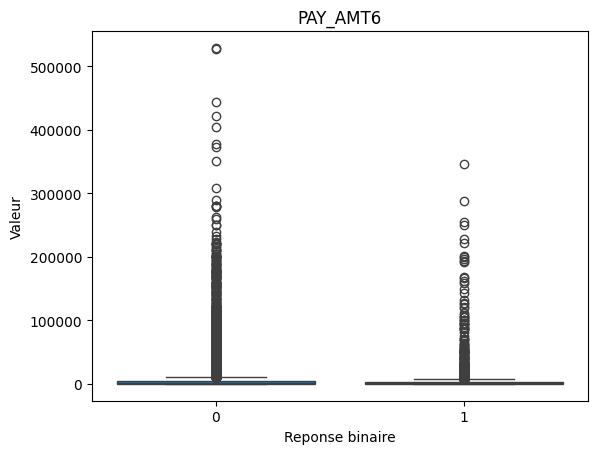

In [23]:
# Générer un box plot pour chaque variable numérique
for var in num_vars:
    sns.boxplot(x='default.payment.next.month', y=var, data=credit_data)
    plt.title(var)
    plt.xlabel('Reponse binaire')
    plt.ylabel('Valeur')
    plt.show()

In [28]:
import scipy.stats as stats
# Initialiser les listes pour stocker les résultats
var_names = []
kw_stats = []
p_values = []

# Parcourir toutes les variables numériques
for var in num_vars:
    # Calculer les groupes de valeurs
    groups = [credit_data[credit_data['default.payment.next.month'] == 0][var], credit_data[credit_data['default.payment.next.month'] == 1][var]]
    # Appliquer le test de Kruskal-Wallis
    kw_stat, p = stats.kruskal(*groups)
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    kw_stats.append(kw_stat)
    p_values.append(p)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Kruskal-Wallis': kw_stats,
    'P-valeur': p_values
})

# Trier le DataFrame par ordre croissant de p-valeur
results_df.sort_values(by='P-valeur', inplace=True)

# Afficher le tableau des résultats
print(results_df)

     Variable  Kruskal-Wallis       P-valeur
0   LIMIT_BAL      862.756409  1.225520e-189
8    PAY_AMT1      772.715560  4.616556e-170
9    PAY_AMT2      683.802429  9.954766e-151
10   PAY_AMT3      582.851233  8.992533e-129
11   PAY_AMT4      491.339268  7.284564e-109
13   PAY_AMT6      442.441975   3.184062e-98
12   PAY_AMT5      407.762871   1.124851e-90
2   BILL_AMT1       19.242804   1.151034e-05
3   BILL_AMT2        7.257338   7.061188e-03
4   BILL_AMT3        4.815637   2.820264e-02
5   BILL_AMT4        2.095146   1.477676e-01
6   BILL_AMT5        1.408132   2.353667e-01
1         AGE        0.795297   3.725031e-01
7   BILL_AMT6        0.000174   9.894802e-01


## Modélisation

In [ ]:
import statsmodels.api as sm
# Sélectionner les variables explicatives et la variable d'intérêt
X = credit_data[['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']]
y = credit_data['default.payment.next.month']

In [80]:

# Ajouter une constante pour l'interception
X = sm.add_constant(X)

In [81]:
# Diviser les données en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
# Créer le modèle de régression logistique
logit_model = sm.Logit(y_train, X_train)

In [83]:
# Ajuster le modèle aux données d'apprentissage
result = logit_model.fit()


Optimization terminated successfully.
         Current function value: 0.466572
         Iterations 7


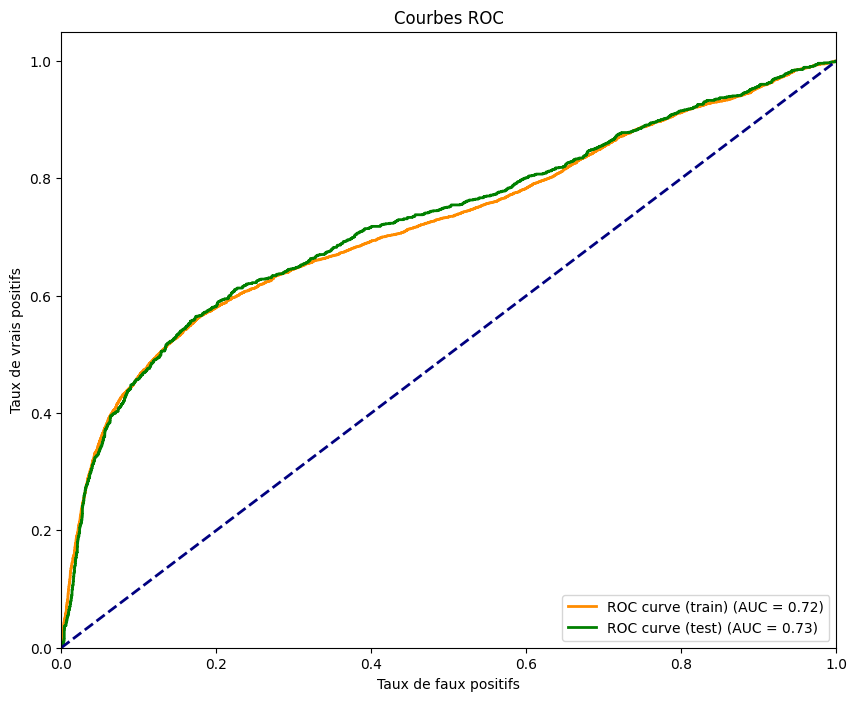

In [84]:
from sklearn.metrics import roc_curve, auc
# Obtenir les prédictions du modèle sur l'ensemble d'entraînement et de test
y_train_pred = result.predict(X_train)
y_test_pred = result.predict(X_test)

# Calculer les courbes ROC et les aires sous la courbe (AUC)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_pred)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='ROC curve (train) (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='ROC curve (test) (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend(loc="lower right")
plt.show()

In [85]:

from sklearn.metrics import classification_report

# Prédire les classes sur la base de test
y_pred = result.predict(X_test) > 0.5

# Générer le rapport de classification
report = classification_report(y_test, y_pred)

# Afficher le rapport de classification
print(report)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.70      0.23      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [86]:

from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[4559  128]
 [1010  303]]


Puisqu'il y a plus de femmes que d'hommes, essayons certaines techniques pour essayer d'améliorer les performances du modèle.

## Oversampling

In [87]:
# Importer les bibliothèques nécessaires
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split


# Diviser les données en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialiser l'objet RandomOverSampler
ros = RandomOverSampler(sampling_strategy=1, random_state=42)

# Appliquer l'oversampling sur les données d'apprentissage
X_train_oversampled, y_train_oversampled = ros.fit_resample(X_train, y_train)

# Créer un nouveau DataFrame avec les données oversampled
bankdata_oversampled = pd.concat([X_train_oversampled, y_train_oversampled], axis=1)

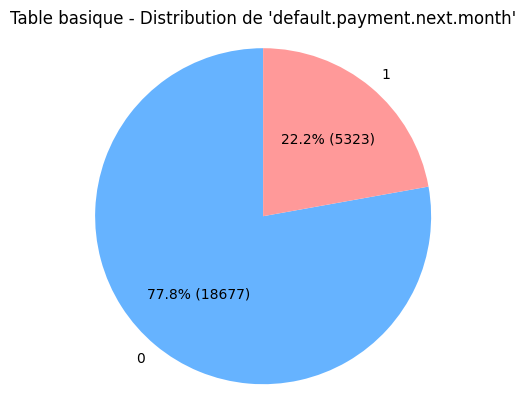

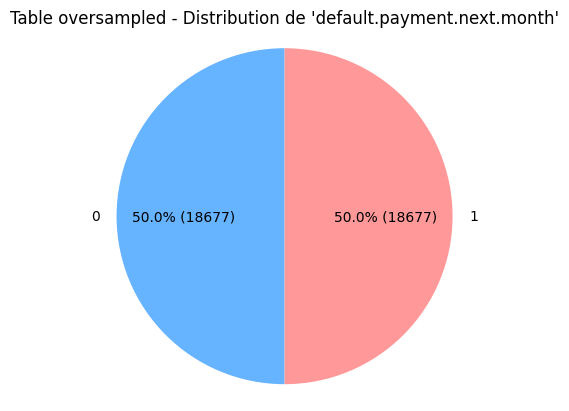

In [89]:
# Fonction pour créer un pie chart avec les proportions et les nombres
def plot_pie_chart(y, title):
    labels = ['0', '1']
    sizes = y.value_counts().values
    colors = ['#66b3ff', '#ff9999']
    
    # Modifier le format des labels pour inclure les proportions et les nombres
    def autopct_format(pct, all_values):
        absolute = int(round(pct / 100 * sum(all_values)))
        return f"{pct:.1f}% ({absolute})"

    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, colors=colors, autopct=lambda pct: autopct_format(pct, sizes), startangle=90)
    ax.axis('equal')  # Pour assurer que le diagramme est bien rond
    plt.title(title)
    plt.show()

# Créer un pie chart pour la table basique
plot_pie_chart(y_train, "Table basique - Distribution de 'default.payment.next.month'")

# Créer un pie chart pour la table oversampled
plot_pie_chart(y_train_oversampled, "Table oversampled - Distribution de 'default.payment.next.month'")

In [90]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

# Entraîner et évaluer la régression logistique sur la base basique
logreg_basique = sm.Logit(y_train, X_train).fit()
y_pred_basique = logreg_basique.predict(X_test)
y_pred_basique_train = logreg_basique.predict(X_train)
auc_basique = roc_auc_score(y_test, y_pred_basique)
auc_train_basique = roc_auc_score(y_train, y_pred_basique_train)
# Entraîner et évaluer la régression logistique sur la base oversampled
logreg_oversampled = sm.Logit(y_train_oversampled, X_train_oversampled).fit(disp=0)
y_pred_oversampled = logreg_oversampled.predict(X_test)
auc_oversampled = roc_auc_score(y_test, y_pred_oversampled)
y_pred_oversampled_train = logreg_oversampled.predict(X_train_oversampled)
auc_oversampled_train = roc_auc_score(y_train_oversampled, y_pred_oversampled_train)

Optimization terminated successfully.
         Current function value: 0.466572
         Iterations 7


In [92]:
# Créer un DataFrame avec les performances
performances = pd.DataFrame({
    'Modèle': ['Base basique', 'Base oversampled'],
    'AUC - Entraînement': [auc_train_basique, auc_oversampled_train],
    'AUC - Test': [auc_basique, auc_oversampled]
})

# Afficher les performances
print(performances)

             Modèle  AUC - Entraînement  AUC - Test
0      Base basique            0.721139    0.726775
1  Base oversampled            0.722141    0.728762


## Il n'y a pas eu de différence significative avec le modèle de base. 

Passons à l'undersampling

In [94]:
# Importer les bibliothèques nécessaires
from imblearn.under_sampling import RandomUnderSampler

# Initialiser l'objet RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)

# Appliquer l'undersampling sur les données d'apprentissage
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)

# Créer un nouveau DataFrame avec les données undersampled
credit_data_undersampled = pd.concat([X_train_undersampled, y_train_undersampled], axis=1)

# Afficher la nouvelle distribution des données
print(credit_data_undersampled['default.payment.next.month'].value_counts())

default.payment.next.month
0    5323
1    5323
Name: count, dtype: int64


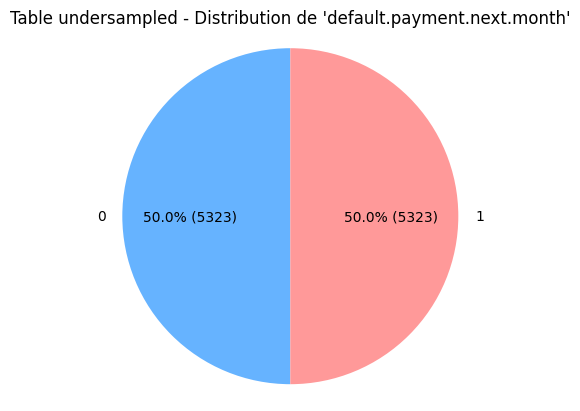

In [95]:
# Créer un pie chart pour la table undersampled
plot_pie_chart(y_train_undersampled, "Table undersampled - Distribution de 'default.payment.next.month'")

In [96]:
# Entraîner et évaluer la régression logistique sur la base oversampled
lr_undersampled = sm.Logit(y_train_undersampled, X_train_undersampled).fit()


y_pred_undersampled = lr_undersampled.predict(X_test)
auc_undersampled = roc_auc_score(y_test, y_pred_undersampled)

# Ajouter les performances de la base undersampled au DataFrame
performances.loc[2] = ['Base undersampled', auc_undersampled, auc_undersampled]

# Afficher les performances
print(performances)

Optimization terminated successfully.
         Current function value: 0.614722
         Iterations 6
              Modèle  AUC - Entraînement  AUC - Test
0       Base basique            0.721139    0.726775
1   Base oversampled            0.722141    0.728762
2  Base undersampled            0.728089    0.728089
